In [27]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.api import VAR
from scipy.stats import ttest_ind
from pandas.tseries.offsets import MonthEnd
import matplotlib.pyplot as plt

Processing Resale Data

Analysis (Distribution)


=== OLS Model 1: log(Resale Price) ~ SORA (levels) ===
                            OLS Regression Results                            
Dep. Variable:       log_resale_price   R-squared:                       0.418
Model:                            OLS   Adj. R-squared:                  0.412
Method:                 Least Squares   F-statistic:                     74.66
Date:                Sat, 15 Nov 2025   Prob (F-statistic):           7.19e-14
Time:                        10:46:56   Log-Likelihood:                 70.936
No. Observations:                 106   AIC:                            -137.9
Df Residuals:                     104   BIC:                            -132.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

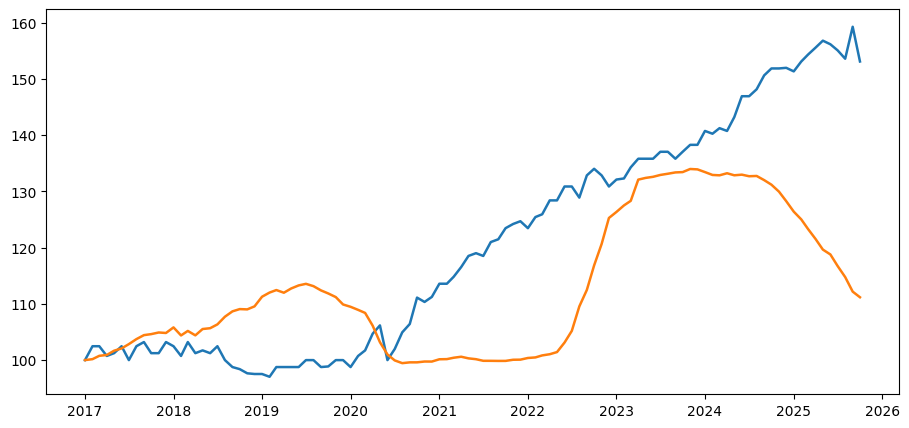

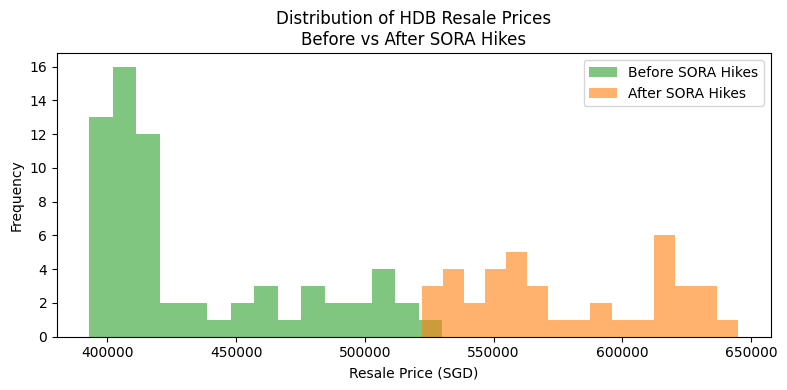

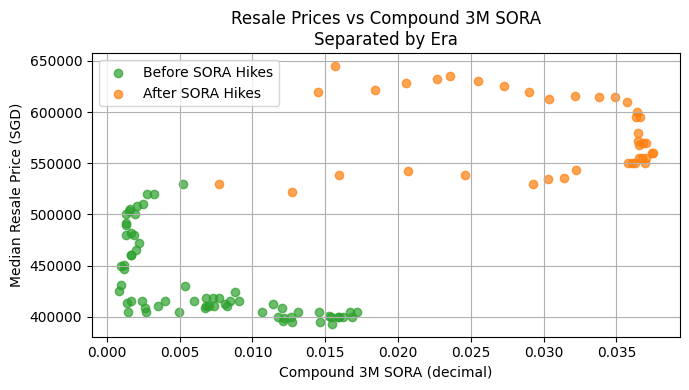

<Figure size 800x400 with 0 Axes>

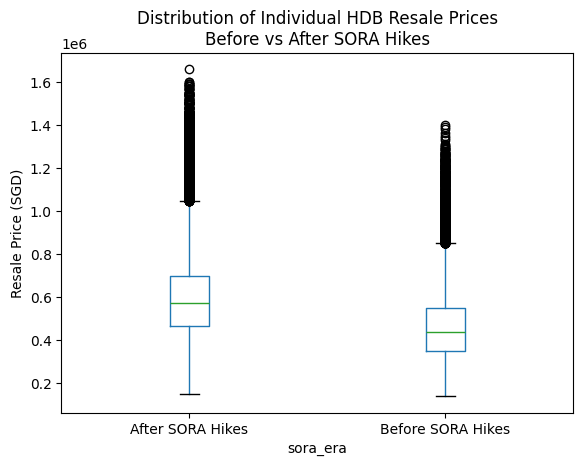

TtestResult(statistic=np.float64(-172.19894111731065), pvalue=np.float64(0.0), df=np.float64(169976.62147335827))


In [28]:
resale_m = (
    resale.assign(month = (resale["month"] + MonthEnd(0)).dt.to_period("M").dt.to_timestamp())
          .groupby("month", as_index=False)
          .agg(median_resale_price=("resale_price","median"))
)

merged = (resale_m.merge(sora[["month","sora_rate"]], on="month", how="left")
                  .dropna(subset=["median_resale_price","sora_rate"])
                  .sort_values("month")
                  .reset_index(drop=True))

# Fit levels model: log(price) ~ sora_rate
merged["log_resale_price"] = np.log(merged["median_resale_price"])
X = sm.add_constant(merged["sora_rate"])
y = merged["log_resale_price"]
ols_levels = sm.OLS(y, X, missing="drop").fit()

# SORA-factored (model-implied) price series
merged["price_factoring_sora"] = np.exp(ols_levels.predict(X))


base_idx = 0 
base_raw  = merged.loc[base_idx, "median_resale_price"]
base_fact = merged.loc[base_idx, "price_factoring_sora"]
merged["raw_idx"]   = 100 * merged["median_resale_price"] / base_raw
merged["sora_idx"]  = 100 * merged["price_factoring_sora"] / base_fact

fig, ax = plt.subplots(figsize=(11,5))


#  indexed to 100 = first point (often clearer when scales differ)
ax.plot(merged["month"], merged["raw_idx"],  label="Resale (Raw, idx=100)", linewidth=1.8)
ax.plot(merged["month"], merged["sora_idx"], label="Resale (Factoring 3M SORA, idx=100)", linewidth=1.8)




# Drop rows with missing values
merged = merged.dropna(subset=["median_resale_price", "sora_rate"]).copy()

# Log transformation (for elasticity interpretation)
merged["log_resale_price"] = np.log(merged["median_resale_price"])
merged["log_sora_rate"] = np.log(merged["sora_rate"])

# -------------  Plot 1: Time-Series Overlay -------------
# plt.figure(figsize=(8,4))
# plt.scatter(merged["sora_rate"], merged["median_resale_price"], alpha=0.7)
# plt.title("HDB Resale Prices vs Compound 3M SORA")
# plt.xlabel("Compound 3M SORA (decimal)")
# plt.ylabel("Median Resale Price (SGD)")
# plt.grid(True)
# plt.show()

# --------------------------------------------
# OLS 1: Levels model
# log(Price_t) = α + β * SORA_t + ε_t
# --------------------------------------------
X1 = sm.add_constant(merged["sora_rate"])
y1 = merged["log_resale_price"]

ols1 = sm.OLS(y1, X1).fit()
print("\n=== OLS Model 1: log(Resale Price) ~ SORA (levels) ===")
print(ols1.summary())

# --------------------------------------------
# OLS 2: Differenced model (month-to-month changes)
# Δlog(Price_t) = α + β * ΔSORA_t + ε_t
# --------------------------------------------
merged["d_log_price"] = merged["log_resale_price"].diff()
merged["d_sora"] = merged["sora_rate"].diff()

diff_df = merged.dropna(subset=["d_log_price","d_sora"])
X2 = sm.add_constant(diff_df["d_sora"])
y2 = diff_df["d_log_price"]

ols2 = sm.OLS(y2, X2).fit()
print("\n=== OLS Model 2: Δlog(Resale Price) ~ ΔSORA (first-difference) ===")
print(ols2.summary())

# --------------------------------------------
# interpret elasticity
# --------------------------------------------
beta1 = ols1.params["sora_rate"]
print(f"\nIn levels: a 1.0 (100 pp) increase in SORA associates with "
      f"{beta1:.3f} change in log-price (~{beta1*100:.1f}% effect).")

beta2 = ols2.params["d_sora"]
print(f"In differences: a 0.01 (100 bp) increase in SORA associates with "
      f"{beta2*100:.2f}% month-to-month price change.")

# ============================================
# Before vs After SORA Rate Hike Visualization
# ============================================


# Define cutoff — June 2022 (SORA started climbing)
cutoff = pd.Timestamp("2022-06-30")

# Tag the period
merged["sora_era"] = np.where(merged["month"] <= cutoff, "Before SORA Hikes", "After SORA Hikes")

# Quick summary stats
summary = merged.groupby("sora_era")["median_resale_price"].describe()[["mean","std","min","max"]]
print("\n=== Summary of Resale Prices by Era ===")
print(summary)


# -------------  Plot 2: Distribution Comparison -------------
plt.figure(figsize=(8,4))
for era, color in zip(["Before SORA Hikes","After SORA Hikes"], ["tab:green","tab:orange"]):
    subset = merged.loc[merged["sora_era"]==era,"median_resale_price"]
    plt.hist(subset, bins=15, alpha=0.6, color=color, label=era)
plt.title("Distribution of HDB Resale Prices\nBefore vs After SORA Hikes")
plt.xlabel("Resale Price (SGD)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# -------------  Plot 3: SORA vs Price scatter by Era -------------
plt.figure(figsize=(7,4))
for era, color in zip(["Before SORA Hikes","After SORA Hikes"], ["tab:green","tab:orange"]):
    plt.scatter(
        merged.loc[merged["sora_era"]==era,"sora_rate"],
        merged.loc[merged["sora_era"]==era,"median_resale_price"],
        alpha=0.7, label=era, color=color)
plt.title("Resale Prices vs Compound 3M SORA\nSeparated by Era")
plt.xlabel("Compound 3M SORA (decimal)")
plt.ylabel("Median Resale Price (SGD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# print(ols_levels.summary())


resale["sora_era"] = np.where(resale["month"] <= cutoff, "Before SORA Hikes", "After SORA Hikes")

plt.figure(figsize=(8,4))
resale.boxplot(column="resale_price", by="sora_era", grid=False)
plt.title("Distribution of Individual HDB Resale Prices\nBefore vs After SORA Hikes")
plt.suptitle("")  # remove auto-title
plt.ylabel("Resale Price (SGD)")
plt.show()


before = resale.loc[resale["sora_era"]=="Before SORA Hikes","resale_price"]
after  = resale.loc[resale["sora_era"]=="After SORA Hikes","resale_price"]
print(ttest_ind(before, after, equal_var=False))

Rental Data

In [ ]:
# Load Rent Data
PATH_RENT = "RentingOutofFlatsfromJan2021_QH.csv"
PATH_SORA = "./QH_Data/Cleaned_SORA_Data_month_start.csv"

rent = pd.read_csv(PATH_RENT)
rent.columns = rent.columns.str.strip().str.lower()

# Ensure all expected columns exist
required_cols = {"crent_approval_date", "town", "block", "street_name", "flat_type", "monthly_rent"}
missing = required_cols - set(rent.columns)
if missing:
    raise ValueError(f"Missing expected columns in rent file: {missing}")

# Convert and clean date
rent["month"] = pd.to_datetime(rent["crent_approval_date"], errors="coerce")
rent["month"] = (rent["month"] + MonthEnd(0)).dt.to_period("M").dt.to_timestamp()

# Convert rent to numeric
rent["monthly_rent"] = pd.to_numeric(rent["monthly_rent"], errors="coerce")

# Monthly median rent
rent_m = rent.groupby("month", as_index=False).agg(median_rent=("monthly_rent", "median"))

rent = pd.read_csv(PATH_RENT)
rent.columns = rent.columns.str.strip().str.lower()

# Ensure all expected columns exist
required_cols = {"crent_approval_date", "town", "block", "street_name", "flat_type", "monthly_rent"}
missing = required_cols - set(rent.columns)
if missing:
    raise ValueError(f"Missing expected columns in rent file: {missing}")

# Convert and clean date
rent["month"] = pd.to_datetime(rent["crent_approval_date"], errors="coerce")
rent["month"] = (rent["month"] + MonthEnd(0)).dt.to_period("M").dt.to_timestamp()

# Convert rent to numeric
rent["monthly_rent"] = pd.to_numeric(rent["monthly_rent"], errors="coerce")

# Monthly median rent
rent_m = rent.groupby("month", as_index=False).agg(median_rent=("monthly_rent", "median"))

# Prepare SORA Data
sora = pd.read_csv(PATH_SORA)
sora.columns = sora.columns.str.strip()

# Data Cleaning / Handling
sora["month"] = pd.to_datetime(sora["month"], errors="coerce")
sora["month"] = (sora["month"] + MonthEnd(0)).dt.to_period("M").dt.to_timestamp()

# Use Compound 3M SORA
if "Compound_SORA_3M" not in sora.columns:
    raise ValueError("Expected column 'Compound_SORA_3M' not found in SORA file")

sora["sora_rate"] = pd.to_numeric(sora["Compound_SORA_3M"], errors="coerce")

# Convert % to decimal
if sora["sora_rate"].median() > 1:
    sora["sora_rate"] = sora["sora_rate"] / 100

sora = sora[["month", "sora_rate"]].sort_values("month")

#Merge Data
merged_rent = rent_m.merge(sora, on="month", how="left").dropna(subset=["median_rent", "sora_rate"])
merged_rent = merged_rent.sort_values("month")

In [34]:
# Model Creation
# Levels model: log(rent) ~ sora_rate
merged_rent["log_rent"] = np.log(merged_rent["median_rent"])
X = sm.add_constant(merged_rent["sora_rate"])
y = merged_rent["log_rent"]
ols_rent = sm.OLS(y, X).fit()

# Predicted rent factoring in SORA
merged_rent["predicted_rent_sora"] = np.exp(ols_rent.predict(X))

# --------------------
# Normalize to index 100 (first month)
# --------------------
base_rent = merged_rent["median_rent"].iloc[0]
base_pred = merged_rent["predicted_rent_sora"].iloc[0]
merged_rent["rent_idx"] = 100 * merged_rent["median_rent"] / base_rent
merged_rent["sora_idx"] = 100 * merged_rent["predicted_rent_sora"] / base_pred

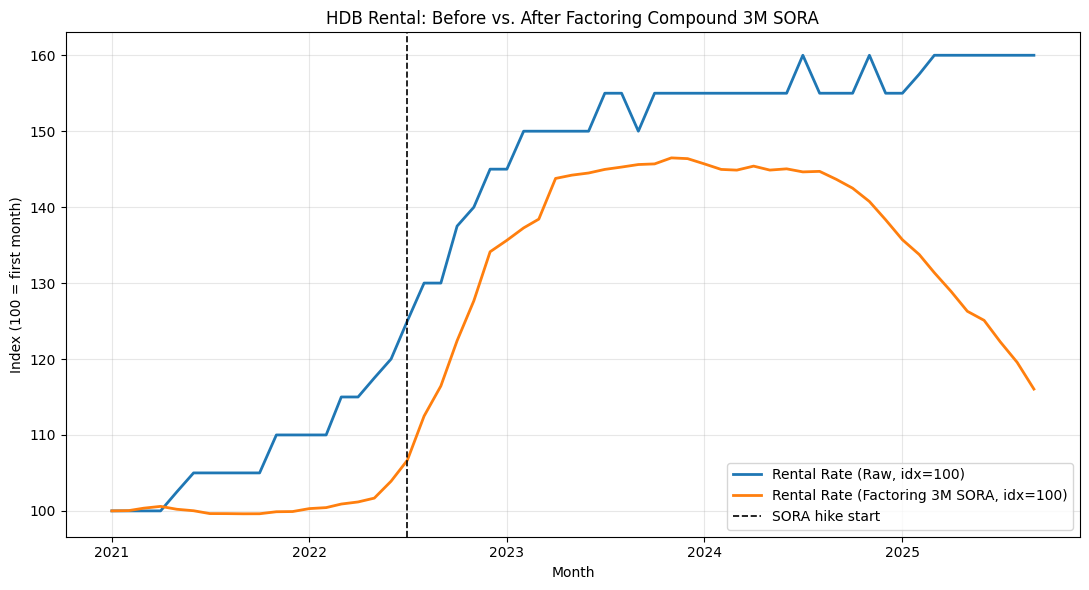

                            OLS Regression Results                            
Dep. Variable:               log_rent   R-squared:                       0.828
Model:                            OLS   Adj. R-squared:                  0.825
Method:                 Least Squares   F-statistic:                     264.3
Date:                Sat, 15 Nov 2025   Prob (F-statistic):           1.16e-22
Time:                        10:55:31   Log-Likelihood:                 69.740
No. Observations:                  57   AIC:                            -135.5
Df Residuals:                      55   BIC:                            -131.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.6819      0.017    453.611      0.0

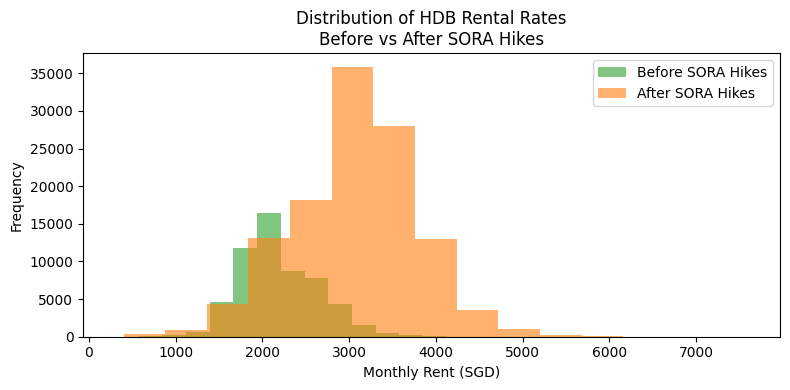

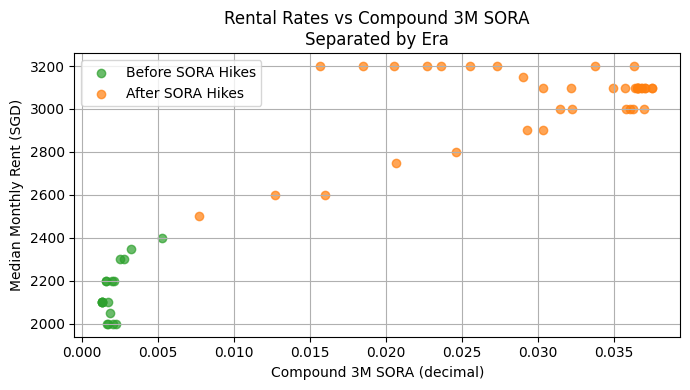

<Figure size 600x500 with 0 Axes>

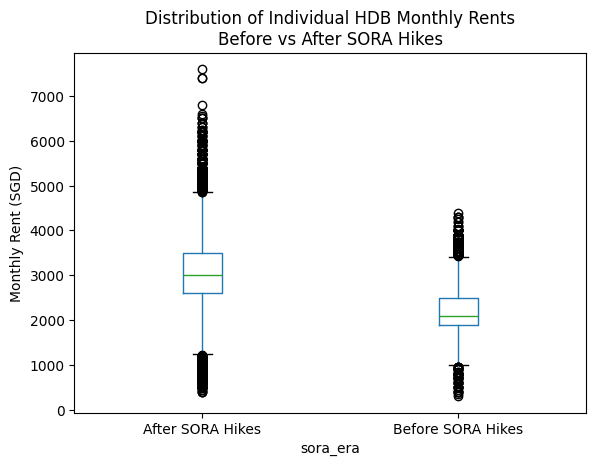

T-test statistic = -307.984, p = 0.0000


In [36]:
# Visualisation

# -------------  Plot 1: Time-Series Overlay -------------
plt.figure(figsize=(11,6))
plt.plot(merged_rent["month"], merged_rent["rent_idx"], label="Rental Rate (Raw, idx=100)", linewidth=2.0, color="tab:blue")
plt.plot(merged_rent["month"], merged_rent["sora_idx"], label="Rental Rate (Factoring 3M SORA, idx=100)", linewidth=2.0, color="tab:orange")

cutoff = pd.Timestamp("2022-06-30")
plt.axvline(cutoff, color="black", linestyle="--", lw=1.2, label="SORA hike start")

plt.title("HDB Rental: Before vs. After Factoring Compound 3M SORA")
plt.xlabel("Month")
plt.ylabel("Index (100 = first month)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(ols_rent.summary())

# Define cutoff for SORA hikes
cutoff = pd.Timestamp("2022-06-30")

# Tag era
rent["month"] = pd.to_datetime(rent["month"], errors="coerce")
rent["sora_era"] = np.where(rent["month"] <= cutoff, "Before SORA Hikes", "After SORA Hikes")

# Distribution Histogram

plt.figure(figsize=(8,4))
for era, color in zip(["Before SORA Hikes","After SORA Hikes"], ["tab:green","tab:orange"]):
    subset = rent.loc[rent["sora_era"]==era,"monthly_rent"]
    plt.hist(subset, bins=15, alpha=0.6, color=color, label=era)
plt.title("Distribution of HDB Rental Rates\nBefore vs After SORA Hikes")
plt.xlabel("Monthly Rent (SGD)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

# Scatter: Rental vs SORA

plt.figure(figsize=(7,4))
for era, color in zip(["Before SORA Hikes","After SORA Hikes"], ["tab:green","tab:orange"]):
    plt.scatter(
        merged_rent.loc[merged_rent["month"].dt.to_period("M").dt.to_timestamp() <= cutoff, "sora_rate"] if era=="Before SORA Hikes"
        else merged_rent.loc[merged_rent["month"].dt.to_period("M").dt.to_timestamp() > cutoff, "sora_rate"],
        merged_rent.loc[merged_rent["month"].dt.to_period("M").dt.to_timestamp() <= cutoff, "median_rent"] if era=="Before SORA Hikes"
        else merged_rent.loc[merged_rent["month"].dt.to_period("M").dt.to_timestamp() > cutoff, "median_rent"],
        alpha=0.7, color=color, label=era)
plt.title("Rental Rates vs Compound 3M SORA\nSeparated by Era")
plt.xlabel("Compound 3M SORA (decimal)")
plt.ylabel("Median Monthly Rent (SGD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Boxplot: Individual Rents

plt.figure(figsize=(6,5))
rent.boxplot(column="monthly_rent", by="sora_era", grid=False)
plt.title("Distribution of Individual HDB Monthly Rents\nBefore vs After SORA Hikes")
plt.suptitle("")  # remove auto-title
plt.ylabel("Monthly Rent (SGD)")
plt.show()

before = rent.loc[rent["sora_era"]=="Before SORA Hikes","monthly_rent"].dropna()
after  = rent.loc[rent["sora_era"]=="After SORA Hikes","monthly_rent"].dropna()
tstat, pval = ttest_ind(before, after, equal_var=False)
print(f"T-test statistic = {tstat:.3f}, p = {pval:.4f}")


=== Correlation Matrix ===
                     sora_rate  median_resale_price  median_rent  \
sora_rate             1.000000             0.677833     0.908871   
median_resale_price   0.677833             1.000000     0.899054   
median_rent           0.908871             0.899054     1.000000   
pricerent_ratio      -0.952240            -0.646922    -0.913985   

                     pricerent_ratio  
sora_rate                  -0.952240  
median_resale_price        -0.646922  
median_rent                -0.913985  
pricerent_ratio             1.000000  


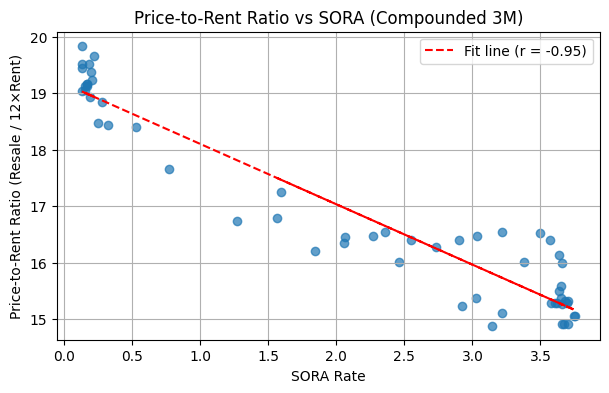


Correlation r = -0.952
p-value = 0.0000


In [41]:
import pandas as pd
import numpy as np
from pandas.tseries.offsets import MonthEnd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Load datasets
resale = pd.read_csv("ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv")
rent   = pd.read_csv("RentingOutofFlatsfromJan2021_QH.csv")
sora   = pd.read_csv(".\QH_Data\Cleaned_SORA_Data_month_start.csv")

# Parse dates
resale["month"] = pd.to_datetime(resale["month"], errors="coerce") + MonthEnd(0)
rent["month"]   = pd.to_datetime(rent["crent_approval_date"], errors="coerce") + MonthEnd(0)

# Convert SORA from month-start → month-end for alignment
sora["month"] = pd.to_datetime(sora["month"], errors="coerce") + MonthEnd(0)
sora = sora.rename(columns={"Compound_SORA_3M": "sora_rate"})

# Monthly median resale price
resale_m = (
    resale.groupby("month", as_index=False)
          .agg(median_resale_price=("resale_price","median"))
)

# Monthly median rent
rent_m = (
    rent.groupby("month", as_index=False)
        .agg(median_rent=("monthly_rent","median"))
)

price_rent = (
    resale_m.merge(rent_m, on="month", how="inner")
            .sort_values("month")
)

# Annualize rent (rent is monthly)
price_rent["pricerent_ratio"] = (
    price_rent["median_resale_price"] / (12 * price_rent["median_rent"])
)
# print(price_rent.head())

price_rent_sora = (
    price_rent.merge(sora[["month", "sora_rate"]], on="month", how="left")
              .dropna(subset=["sora_rate"])
              .sort_values("month")
)

# print(price_rent_sora.head())

corr_matrix = price_rent_sora[["sora_rate", "median_resale_price", "median_rent", "pricerent_ratio"]].corr()
print("\n=== Correlation Matrix ===")
print(corr_matrix)


x = price_rent_sora["sora_rate"]
y = price_rent_sora["pricerent_ratio"]

slope, intercept, r_value, p_value, std_err = linregress(x, y)

plt.figure(figsize=(7,4))
plt.scatter(x, y, alpha=0.7)
plt.plot(x, intercept + slope*x, color="red", linestyle="--",
         label=f"Fit line (r = {r_value:.2f})")

plt.title("Price-to-Rent Ratio vs SORA (Compounded 3M)")
plt.xlabel("SORA Rate")
plt.ylabel("Price-to-Rent Ratio (Resale / 12×Rent)")
plt.legend()
plt.grid(True)
plt.show()

print(f"\nCorrelation r = {r_value:.3f}")
print(f"p-value = {p_value:.4f}")



